# Vietnamese Speech Toxicity Detection -- AST Fine-tuning Pipeline

A single, linear, end-to-end pipeline for binary toxic/non-toxic classification of Vietnamese speech utterances, fine-tuning the pretrained **AST (Audio Spectrogram Transformer)** -- `MIT/ast-finetuned-audioset-10-10-0.4593` -- on the ViToSA dataset (`antspham/vietnamese-toxic-utterance-detection-banlanced`, v5.2).

This is a streamlined rewrite of an earlier 11-model benchmark notebook: everything not needed to fine-tune and evaluate AST well -- the other ten architectures, the multi-model registry, the scientific-benchmark scaffolding -- has been removed. What is kept is one clean pass through the workflow a practitioner actually runs for a single model:

```
Kaggle-aware dataset resolution
        |
        v
Load CSV + EDA (class balance, split balance, duration distribution, sample spectrograms)
        |
        v
Waveform preprocessing (mono, resample to 16 kHz, fixed-length, normalize)
        |
        v
Train-only augmentation (gain, time shift, Gaussian noise)
        |
        v
AST feature extraction (per-sample, in the Dataset -- parallelized across DataLoader workers)
        |
        v
PyTorch Dataset / DataLoader (class-balanced sampling)
        |
        v
AST fine-tuning (AdamW, cosine LR, AMP, early stopping, best-checkpoint by validation F1)
        |
        v
Test-set evaluation (accuracy, precision, recall, F1, balanced accuracy, MCC, AUROC, AUPRC)
        |
        v
Visualization (training curves, confusion matrix, ROC, precision-recall)
        |
        v
Save checkpoint + metrics report
```

Everything tunable -- dataset paths, audio parameters, augmentation strength, training hyperparameters -- lives in one `CONFIG` dict in Section 1, so re-running this on a new dataset drop or with different hyperparameters means editing one cell, not hunting through the notebook.

Run cells top to bottom on a Kaggle GPU notebook (T4/P100) with the ViToSA dataset attached.


## 1. Environment setup

In [1]:
# ============================================================
# ENVIRONMENT SETUP
# ============================================================
import importlib
import os
import random
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore")


def _ensure(pkg_import_name, pip_name=None):
    pip_name = pip_name or pkg_import_name
    try:
        importlib.import_module(pkg_import_name)
    except ImportError:
        print(f"[setup] installing {pip_name} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", pip_name], check=True)


for _import_name, _pip_name in [
    ("torch", "torch"),
    ("torchaudio", "torchaudio"),
    ("transformers", "transformers>=4.40"),
    ("sklearn", "scikit-learn"),
    ("pandas", "pandas"),
    ("seaborn", "seaborn"),
    ("soundfile", "soundfile"),
]:
    try:
        _ensure(_import_name, _pip_name)
    except Exception as exc:
        print(f"[setup] WARNING: could not verify/install {_pip_name}: {exc}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm

IS_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or os.path.isdir("/kaggle/input")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("ENVIRONMENT")
print("=" * 70)
print(f"Running on Kaggle : {IS_KAGGLE}")
print(f"Device            : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU               : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory        : {torch.cuda.get_device_properties(0).total_memory / (1024 ** 3):.1f} GB")
    torch.backends.cudnn.benchmark = True
else:
    print("No GPU detected -- training will fall back to CPU and will be slow.")
print(f"PyTorch           : {torch.__version__}")
import transformers as _tf
print(f"Transformers      : {_tf.__version__}")
print("=" * 70)


ENVIRONMENT
Running on Kaggle : True
Device            : cuda
GPU               : Tesla T4
GPU memory        : 14.6 GB
PyTorch           : 2.10.0+cu128
Transformers      : 5.0.0


## 2. Configuration

Single source of truth for the whole notebook. Edit this cell to point at a different dataset drop, change augmentation strength, or retune training -- nothing else needs to change.

In [2]:
# ============================================================
# CONFIG -- single source of truth
# ============================================================
from pathlib import Path

CONFIG = {
    "seed": 42,

    "paths": {
        # Primary target: antspham/vietnamese-toxic-utterance-detection-banlanced, v5.2
        "csv_filename": "final_vietnamese_toxic_utterance_dataset_v5.1.2_speaker_split.csv",
        "audio_folder_name": "wav_segments_v5.2",
        "kaggle_input_root": "/kaggle/input",
        # Fallback search roots when not running on Kaggle / dataset not under /kaggle/input.
        "local_dataset_dirs": ["../vitosa_datasets", "vitosa_datasets", "./data", "."],
    },

    "columns": {"audio": "audio_path", "label": "toxicity", "split": "split", "duration": "duration"},

    "audio": {
        "sample_rate": 16000,
        "max_seconds": 8.0,
    },

    "augment": {
        "gain_min": 0.80, "gain_max": 1.20, "gain_prob": 0.50,
        "time_shift_max_seconds": 0.50, "time_shift_prob": 0.50,
        "noise_std": 0.003, "noise_prob": 0.50,
    },

    "model": {
        "checkpoint": "MIT/ast-finetuned-audioset-10-10-0.4593",
        "num_labels": 1,
        # 0 = fully fine-tune (best accuracy, ~86M trainable params, fits a 16GB GPU
        # fine at the batch size below). Raise this to freeze the first N encoder
        # layers if you need faster epochs / less GPU memory at some accuracy cost.
        "freeze_first_n_layers": 0,
    },

    "train": {
        "epochs": 10,
        "batch_size": 16,
        "lr": 2e-5,
        "weight_decay": 1e-2,
        "grad_clip_norm": 1.0,
        "early_stopping_patience": 4,
        "num_workers": 2,
        "use_amp": True,
    },

    "output": {
        "checkpoint_name": "best_ast_toxic_classifier.pt",
        "metrics_name": "test_metrics.json",
    },
}

RANDOM_STATE = CONFIG["seed"]
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


def get_working_dir() -> Path:
    """/kaggle/working on Kaggle, otherwise the current directory."""
    if IS_KAGGLE and os.path.isdir("/kaggle/working"):
        return Path("/kaggle/working")
    return Path.cwd()


WORKING_DIR = get_working_dir()
WORKING_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORKING_DIR.resolve())
print("Random seed       :", RANDOM_STATE)
print("Model checkpoint  :", CONFIG["model"]["checkpoint"])


Working directory: /kaggle/working
Random seed       : 42
Model checkpoint  : MIT/ast-finetuned-audioset-10-10-0.4593


## 3. Load dataset

Resolves the dataset path automatically: searches every dataset attached under `/kaggle/input` (recursively, since Kaggle exports sometimes nest folders a level or two deep -- this dataset in particular stores its audio at `wav_segments_v5.2/wav_segments_v5.2/*.wav`, nested inside itself) and falls back to a few local directories when not running on Kaggle. No hardcoded absolute path.

In [3]:
# ============================================================
# 3.1 DATASET PATH RESOLUTION
# ============================================================

def _dir_has_wav(d: Path) -> bool:
    try:
        return next(d.glob("*.wav"), None) is not None
    except OSError:
        return False


def _find_audio_folder(base_dir: Path, folder_name: str):
    p = base_dir / folder_name
    if not p.is_dir():
        return None
    if _dir_has_wav(p):
        return p
    # Some Kaggle exports nest the folder inside itself, e.g. audio actually
    # lives at .../wav_segments_v5.2/wav_segments_v5.2/*.wav.
    nested = p / folder_name
    if nested.is_dir() and _dir_has_wav(nested):
        return nested
    # Otherwise take the first subdirectory under the named match that
    # directly holds .wav files.
    for sub_dir in sorted(p.rglob("*")):
        if sub_dir.is_dir() and _dir_has_wav(sub_dir):
            return sub_dir
    return None


def resolve_dataset(config):
    csv_name = config["paths"]["csv_filename"]
    audio_folder_name = config["paths"]["audio_folder_name"]

    search_roots = [Path(d).resolve() for d in config["paths"]["local_dataset_dirs"]]

    kaggle_root = Path(config["paths"]["kaggle_input_root"])
    if IS_KAGGLE and kaggle_root.is_dir():
        for top in sorted(kaggle_root.iterdir()):
            if top.is_dir():
                search_roots.append(top)

    tried = []
    for root in search_roots:
        if not root.is_dir():
            tried.append(str(root))
            continue

        direct = root / csv_name
        csv_path = direct if direct.is_file() else next(root.rglob(csv_name), None)
        tried.append(str(root / csv_name))

        if csv_path is not None and csv_path.is_file():
            base_dir = csv_path.parent
            audio_dir = _find_audio_folder(base_dir, audio_folder_name) or _find_audio_folder(base_dir.parent, audio_folder_name)
            if audio_dir is not None:
                return csv_path, audio_dir

    raise FileNotFoundError(
        "Could not locate the dataset. Tried:\n" + "\n".join(f"  - {t}" for t in tried[:40])
        + "\n\nFix: attach the dataset via 'Add Data' on Kaggle, or update "
        "CONFIG['paths'] to match your dataset's actual filenames/layout."
    )


FULL_CSV, AUDIO_DIR = resolve_dataset(CONFIG)

print("=" * 70)
print("DATASET LOCATION")
print("=" * 70)
print(f"CSV   : {FULL_CSV}")
print(f"Audio : {AUDIO_DIR}")


DATASET LOCATION
CSV   : /kaggle/input/datasets/antspham/vietnamese-toxic-utterance-detection-banlanced/final_vietnamese_toxic_utterance_dataset_v5.1.2_speaker_split.csv
Audio : /kaggle/input/datasets/antspham/vietnamese-toxic-utterance-detection-banlanced/wav_segments_v5.2/wav_segments_v5.2


In [4]:
# ============================================================
# 3.2 LOAD + VALIDATE CSV
# ============================================================
cols = CONFIG["columns"]

full_df = pd.read_csv(FULL_CSV)

missing_columns = {cols["audio"], cols["label"], cols["split"]} - set(full_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

# Normalize split labels and drop anything outside train/val/test.
full_df[cols["split"]] = full_df[cols["split"]].astype(str).str.strip().str.lower()
full_df[cols["split"]] = full_df[cols["split"]].replace({"validation": "val"})
full_df = full_df[full_df[cols["split"]].isin(["train", "val", "test"])].copy()

# Resolve every audio filename to an absolute path and verify it exists.
full_df["audio_full_path"] = full_df[cols["audio"]].apply(
    lambda name: str((AUDIO_DIR / Path(str(name)).name).resolve())
)
full_df["audio_exists"] = full_df["audio_full_path"].apply(os.path.isfile)

missing_audio = full_df[~full_df["audio_exists"]]
if len(missing_audio) > 0:
    print(f"[WARNING] {len(missing_audio):,} rows reference a WAV file that does not exist -- dropping them.")
    print(missing_audio[[cols["audio"], "audio_full_path"]].head(10))
    full_df = full_df[full_df["audio_exists"]].reset_index(drop=True)

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total usable samples: {len(full_df):,}")
print("\nLabel distribution:")
print(full_df[cols["label"]].value_counts())
print("\nSplit x label:")
print(pd.crosstab(full_df[cols["split"]], full_df[cols["label"]]))


DATASET SUMMARY
Total usable samples: 24,693

Label distribution:
toxicity
0    12366
1    12327
Name: count, dtype: int64

Split x label:
toxicity     0     1
split               
test      1000  1000
train     8968  8946
val       2398  2381


## 4. Exploratory data analysis

Class balance, split balance, and clip-duration distribution -- the three things that most affect how training should be set up (sampler weighting, loss weighting, `max_seconds`).

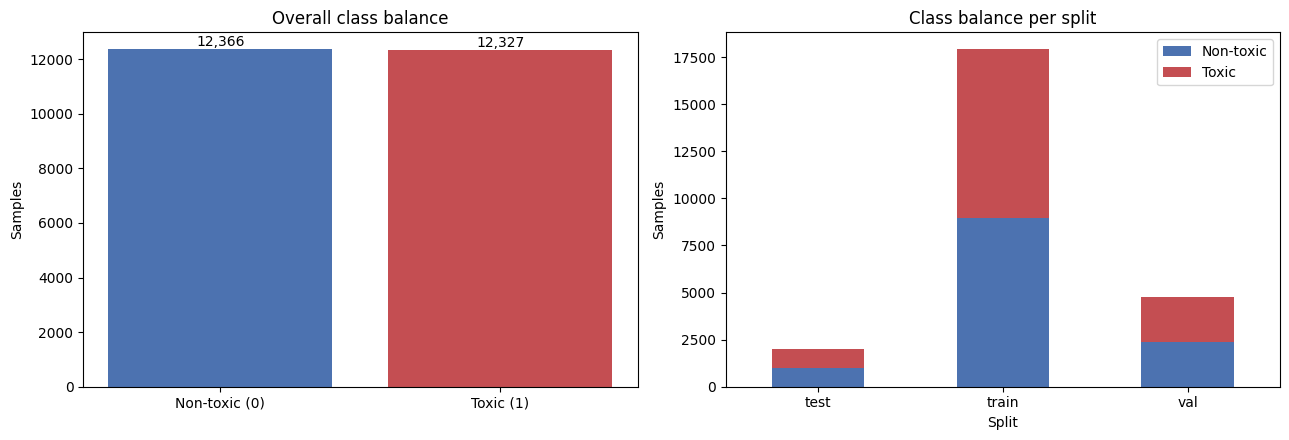

Toxic ratio (overall): 49.9%


In [5]:
# ============================================================
# 4.1 CLASS + SPLIT BALANCE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

label_counts = full_df[cols["label"]].value_counts().sort_index()
axes[0].bar(["Non-toxic (0)", "Toxic (1)"], label_counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")
axes[0].set_title("Overall class balance")
axes[0].set_ylabel("Samples")

split_label = pd.crosstab(full_df[cols["split"]], full_df[cols["label"]])
split_label.plot(kind="bar", stacked=True, ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Class balance per split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Samples")
axes[1].legend(["Non-toxic", "Toxic"])
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

toxic_ratio = label_counts.get(1, 0) / label_counts.sum()
print(f"Toxic ratio (overall): {toxic_ratio:.1%}")


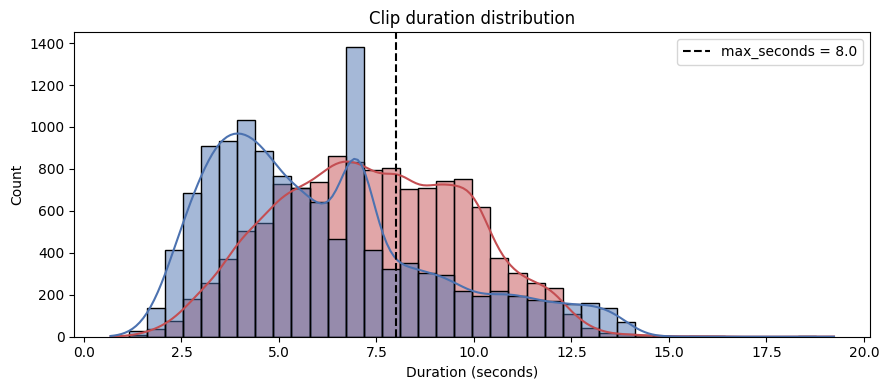

Duration stats (s): count    24693.000000
mean         6.767790
std          2.709025
min          0.682438
25%          4.584000
50%          6.613000
75%          8.700000
max         19.232688

Share of clips longer than max_seconds (will be truncated): 31.7%


In [6]:
# ============================================================
# 4.2 DURATION DISTRIBUTION
# ============================================================
if cols["duration"] in full_df.columns:
    plt.figure(figsize=(9, 4))
    sns.histplot(data=full_df, x=cols["duration"], hue=cols["label"], bins=40, kde=True, palette=["#4C72B0", "#C44E52"])
    plt.axvline(CONFIG["audio"]["max_seconds"], color="black", linestyle="--", label=f'max_seconds = {CONFIG["audio"]["max_seconds"]}')
    plt.title("Clip duration distribution")
    plt.xlabel("Duration (seconds)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    over_limit = (full_df[cols["duration"]] > CONFIG["audio"]["max_seconds"]).mean()
    print(f"Duration stats (s): {full_df[cols['duration']].describe().to_string()}")
    print(f"\nShare of clips longer than max_seconds (will be truncated): {over_limit:.1%}")
else:
    print(f"No '{cols['duration']}' column found -- skipping duration analysis.")


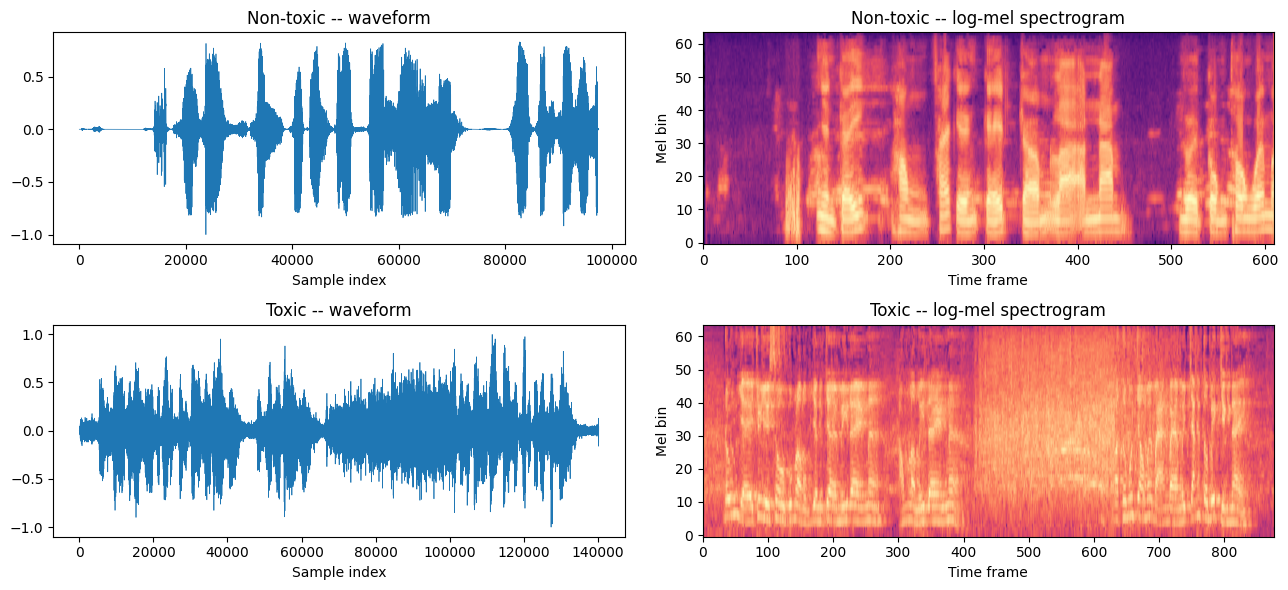

In [7]:
# ============================================================
# 4.3 SAMPLE WAVEFORMS / SPECTROGRAMS -- ONE TOXIC, ONE NON-TOXIC
# ============================================================
_mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=CONFIG["audio"]["sample_rate"], n_mels=64, n_fft=400, hop_length=160)
_db_transform = torchaudio.transforms.AmplitudeToDB()

_sample_rows = [
    full_df[full_df[cols["label"]] == 0].iloc[0],
    full_df[full_df[cols["label"]] == 1].iloc[0],
]

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for row_idx, row in enumerate(_sample_rows):
    waveform, sr = torchaudio.load(row["audio_full_path"])
    waveform = waveform.mean(dim=0, keepdim=True)
    if sr != CONFIG["audio"]["sample_rate"]:
        waveform = torchaudio.functional.resample(waveform, sr, CONFIG["audio"]["sample_rate"])

    label_str = "Toxic" if row[cols["label"]] == 1 else "Non-toxic"

    axes[row_idx, 0].plot(waveform.squeeze(0).numpy(), linewidth=0.5)
    axes[row_idx, 0].set_title(f"{label_str} -- waveform")
    axes[row_idx, 0].set_xlabel("Sample index")

    mel_db = _db_transform(_mel_transform(waveform)).squeeze(0).numpy()
    axes[row_idx, 1].imshow(mel_db, origin="lower", aspect="auto", cmap="magma")
    axes[row_idx, 1].set_title(f"{label_str} -- log-mel spectrogram")
    axes[row_idx, 1].set_xlabel("Time frame")
    axes[row_idx, 1].set_ylabel("Mel bin")

plt.tight_layout()
plt.show()


## 5. Train / validation / test split

The dataset ships with a pre-computed speaker-independent `split` column (`train`/`val`/`test`) -- reused as-is rather than re-splitting, since a fresh random split could leak the same speaker's voice across train and test.

In [8]:
# ============================================================
# 5.1 SPLIT
# ============================================================
train_df = full_df[full_df[cols["split"]] == "train"].sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
val_df = full_df[full_df[cols["split"]] == "val"].reset_index(drop=True)
test_df = full_df[full_df[cols["split"]] == "test"].reset_index(drop=True)

if min(len(train_df), len(val_df), len(test_df)) == 0:
    raise ValueError("One of train/val/test is empty -- check the 'split' column.")

for name, df_ in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = df_[cols["label"]].value_counts().sort_index()
    print(f"{name:5s}: {len(df_):6,} samples | non-toxic={counts.get(0, 0):,} | toxic={counts.get(1, 0):,}")


Train: 17,914 samples | non-toxic=8,968 | toxic=8,946
Val  :  4,779 samples | non-toxic=2,398 | toxic=2,381
Test :  2,000 samples | non-toxic=1,000 | toxic=1,000


## 6. Audio preprocessing & augmentation

Every clip is converted to mono, resampled to 16 kHz, and fixed to `max_seconds` (zero-padded if shorter, truncated if longer) before it ever reaches the model. Training clips additionally get light, on-the-fly waveform augmentation -- random gain, a small time shift, and additive Gaussian noise -- to reduce overfitting; validation and test clips are never augmented.

In [9]:
# ============================================================
# 6.1 WAVEFORM LOADING + FIXED LENGTH
# ============================================================

def load_waveform(path: str, sample_rate: int) -> torch.Tensor:
    """Load a WAV file as a mono, resampled 1-D waveform tensor."""
    waveform, orig_sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if orig_sr != sample_rate:
        waveform = torchaudio.functional.resample(waveform, orig_sr, sample_rate)
    return waveform.squeeze(0)


def fix_length(waveform: torch.Tensor, num_samples: int) -> torch.Tensor:
    """Zero-pad or truncate a 1-D waveform to exactly `num_samples`."""
    if waveform.numel() < num_samples:
        return F.pad(waveform, (0, num_samples - waveform.numel()))
    return waveform[:num_samples]


def normalize_waveform(waveform: torch.Tensor) -> torch.Tensor:
    """Zero-mean, peak-normalize to roughly [-1, 1]."""
    waveform = waveform - waveform.mean()
    return waveform / (waveform.abs().max() + 1e-6)


# ============================================================
# 6.2 TRAIN-ONLY AUGMENTATION
# ============================================================

def augment_waveform(waveform: torch.Tensor, cfg: dict, sample_rate: int) -> torch.Tensor:
    """Random gain, time shift, and Gaussian noise -- applied independently per clip."""
    if random.random() < cfg["gain_prob"]:
        waveform = waveform * random.uniform(cfg["gain_min"], cfg["gain_max"])

    if random.random() < cfg["time_shift_prob"]:
        max_shift = int(sample_rate * cfg["time_shift_max_seconds"])
        shift = random.randint(-max_shift, max_shift)
        if shift != 0:
            shifted = torch.zeros_like(waveform)
            if shift > 0:
                shifted[shift:] = waveform[:-shift]
            else:
                shifted[:shift] = waveform[-shift:]
            waveform = shifted

    if random.random() < cfg["noise_prob"]:
        waveform = waveform + torch.randn_like(waveform) * cfg["noise_std"]

    return waveform.clamp(-1.0, 1.0)


## 7. PyTorch Dataset & DataLoader

`ASTFeatureExtractor` turns a waveform into AST's expected log-mel patch input. It is called once per **sample** inside `__getitem__` (not once per **batch** inside the model's `forward()`), so the CPU work runs in parallel across `num_workers` DataLoader processes instead of serializing on the main training loop -- and because every waveform is already fixed to the same length, `ASTFeatureExtractor` always produces a fixed-size feature tensor, so the default `collate_fn` can just stack them.

A `WeightedRandomSampler` balances the toxic / non-toxic classes during training; validation and test use the natural (imbalanced) distribution, since that is what the model will see in production.

In [10]:
# ============================================================
# 7.1 AST FEATURE EXTRACTOR (shared by Dataset and Model)
# ============================================================
from transformers import ASTFeatureExtractor

feature_extractor = ASTFeatureExtractor.from_pretrained(CONFIG["model"]["checkpoint"])
print("Loaded feature extractor:", CONFIG["model"]["checkpoint"])
print("Expected input          :", feature_extractor.num_mel_bins, "mel bins x", feature_extractor.max_length, "frames")


# ============================================================
# 7.2 DATASET
# ============================================================
class ToxicASTDataset(Dataset):
    """Wraps a dataframe of (audio path, label) into AST-ready input features."""

    def __init__(self, dataframe, feature_extractor, audio_cfg, augment_cfg=None, is_train=False):
        self.df = dataframe.reset_index(drop=True)
        self.feature_extractor = feature_extractor
        self.sample_rate = audio_cfg["sample_rate"]
        self.num_samples = int(audio_cfg["sample_rate"] * audio_cfg["max_seconds"])
        self.augment_cfg = augment_cfg
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        waveform = load_waveform(row["audio_full_path"], self.sample_rate)
        waveform = fix_length(waveform, self.num_samples)
        waveform = normalize_waveform(waveform)

        if self.is_train and self.augment_cfg is not None:
            waveform = augment_waveform(waveform, self.augment_cfg, self.sample_rate)

        features = self.feature_extractor(
            waveform.numpy(), sampling_rate=self.sample_rate, return_tensors="pt"
        )
        input_values = features["input_values"].squeeze(0)  # [time_frames, n_mels]
        label = torch.tensor(float(row[cols["label"]]), dtype=torch.float32)

        return input_values, label


train_dataset = ToxicASTDataset(train_df, feature_extractor, CONFIG["audio"], CONFIG["augment"], is_train=True)
val_dataset = ToxicASTDataset(val_df, feature_extractor, CONFIG["audio"], is_train=False)
test_dataset = ToxicASTDataset(test_df, feature_extractor, CONFIG["audio"], is_train=False)

# ============================================================
# 7.3 CLASS-BALANCED SAMPLER (train only)
# ============================================================
train_labels = train_df[cols["label"]].to_numpy()
class_counts = np.bincount(train_labels.astype(int))
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels.astype(int)]

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(train_labels),
    replacement=True,
)

# ============================================================
# 7.4 DATALOADERS
# ============================================================
train_loader = DataLoader(
    train_dataset, batch_size=CONFIG["train"]["batch_size"], sampler=train_sampler,
    num_workers=CONFIG["train"]["num_workers"], pin_memory=torch.cuda.is_available(), drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG["train"]["batch_size"], shuffle=False,
    num_workers=CONFIG["train"]["num_workers"], pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG["train"]["batch_size"], shuffle=False,
    num_workers=CONFIG["train"]["num_workers"], pin_memory=torch.cuda.is_available(),
)

_sample_input, _sample_label = train_dataset[0]
print(f"Per-sample input shape : {tuple(_sample_input.shape)}")
print(f"Train / Val / Test     : {len(train_dataset):,} / {len(val_dataset):,} / {len(test_dataset):,}")


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Loaded feature extractor: MIT/ast-finetuned-audioset-10-10-0.4593
Expected input          : 128 mel bins x 1024 frames
Per-sample input shape : (1024, 128)
Train / Val / Test     : 17,914 / 4,779 / 2,000


## 8. Model: AST (Audio Spectrogram Transformer)

**Paper:** Gong et al., *AST: Audio Spectrogram Transformer* (2021). A pure Vision-Transformer-style architecture applied directly to log-mel spectrogram patches, pretrained on AudioSet.

**Checkpoint:** `MIT/ast-finetuned-audioset-10-10-0.4593` -- AudioSet-finetuned, 527-way. The 527-class classification head is discarded (`ignore_mismatched_sizes=True`) and replaced by a fresh single-logit head for binary toxic/non-toxic classification; the pretrained spectrogram-transformer backbone is fine-tuned end to end by default (`freeze_first_n_layers = 0` in `CONFIG`).

In [11]:
# ============================================================
# 8.1 MODEL
# ============================================================
from transformers import ASTForAudioClassification


class ASTToxicClassifier(nn.Module):
    """AST backbone + a binary (single-logit) classification head."""

    def __init__(self, checkpoint: str, num_labels: int = 1, freeze_first_n_layers: int = 0):
        super().__init__()
        self.ast = ASTForAudioClassification.from_pretrained(
            checkpoint, num_labels=num_labels, ignore_mismatched_sizes=True
        )

        if freeze_first_n_layers > 0:
            encoder_layers = self.ast.audio_spectrogram_transformer.encoder.layer
            self.ast.audio_spectrogram_transformer.embeddings.requires_grad_(False)
            for layer in encoder_layers[:freeze_first_n_layers]:
                layer.requires_grad_(False)
            print(f"Froze embeddings + first {freeze_first_n_layers}/{len(encoder_layers)} encoder layers.")

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        return self.ast(input_values=input_values).logits


def count_parameters(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model = ASTToxicClassifier(
    checkpoint=CONFIG["model"]["checkpoint"],
    num_labels=CONFIG["model"]["num_labels"],
    freeze_first_n_layers=CONFIG["model"]["freeze_first_n_layers"],
).to(DEVICE)

total_params, trainable_params = count_parameters(model)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,} ({trainable_params / total_params:.1%})")

# Smoke test: one real batch through the model before committing to a full run.
with torch.no_grad():
    _batch_x, _batch_y = next(iter(train_loader))
    _logits = model(_batch_x.to(DEVICE))
    assert _logits.shape == (_batch_x.shape[0], 1), f"unexpected logits shape {tuple(_logits.shape)}"
    print(f"Smoke test OK -- input {tuple(_batch_x.shape)} -> logits {tuple(_logits.shape)}")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([1])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([1, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Total params     : 86,189,569
Trainable params : 86,189,569 (100.0%)
Smoke test OK -- input (16, 1024, 128) -> logits (16, 1)


In [12]:
# Model 

## 9. Training setup

`BCEWithLogitsLoss` with a `pos_weight` computed from the train split's class ratio -- a standard, simple way to counteract label imbalance without needing a custom loss. `AdamW` + cosine annealing LR, matching what pretrained-transformer fine-tuning generally responds well to.

In [13]:
# ============================================================
# 9.1 LOSS -- class-imbalance-aware BCE
# ============================================================
num_neg = int((train_labels == 0).sum())
num_pos = int((train_labels == 1).sum())
pos_weight = torch.tensor(num_neg / max(num_pos, 1), dtype=torch.float32, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Train class counts -- non-toxic: {num_neg:,} | toxic: {num_pos:,}")
print(f"pos_weight (non-toxic/toxic)   : {pos_weight.item():.3f}")

# ============================================================
# 9.2 OPTIMIZER + SCHEDULER
# ============================================================
optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=CONFIG["train"]["lr"],
    weight_decay=CONFIG["train"]["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["train"]["epochs"], eta_min=CONFIG["train"]["lr"] * 0.05
)
scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["train"]["use_amp"] and torch.cuda.is_available())

print(f"Optimizer: AdamW | lr={CONFIG['train']['lr']} | weight_decay={CONFIG['train']['weight_decay']}")
print(f"Scheduler: CosineAnnealingLR over {CONFIG['train']['epochs']} epochs")
print(f"AMP      : {scaler.is_enabled()}")


Train class counts -- non-toxic: 8,968 | toxic: 8,946
pos_weight (non-toxic/toxic)   : 1.002
Optimizer: AdamW | lr=2e-05 | weight_decay=0.01
Scheduler: CosineAnnealingLR over 10 epochs
AMP      : True


## 10. Training & validation loop

`run_epoch()` is shared by both phases (`train=True/False`); it returns the average loss plus every prediction, so downstream code can compute whatever metric it needs (including picking the classification threshold that maximizes validation F1, rather than assuming 0.5).

In [14]:
# ============================================================
# 10.1 SHARED EPOCH RUNNER
# ============================================================

def run_epoch(model, loader, criterion, optimizer, scaler, device, train: bool):
    model.train(train)
    total_loss = 0.0
    all_targets, all_probs = [], []

    phase = "Train" if train else "Valid"
    progress = tqdm(loader, desc=phase, leave=False)

    for input_values, labels in progress:
        input_values = input_values.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).view(-1, 1)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train), torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
            logits = model(input_values)
            loss = criterion(logits, labels)

        if train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["train"]["grad_clip_norm"])
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * input_values.size(0)
        all_targets.extend(labels.detach().cpu().view(-1).tolist())
        all_probs.extend(torch.sigmoid(logits).detach().cpu().view(-1).tolist())
        progress.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_targets), np.array(all_probs)


# ============================================================
# 10.2 THRESHOLD SELECTION + METRICS
# ============================================================
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
)


def select_best_threshold(y_true, probs, grid=np.linspace(0.05, 0.95, 19)):
    """Pick the decision threshold that maximizes F1 on the given (validation) set."""
    best_threshold, best_f1 = 0.5, -1.0
    for t in grid:
        f1 = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_threshold = f1, float(t)
    return best_threshold, best_f1


def compute_metrics(y_true, probs, threshold):
    y_pred = (probs >= threshold).astype(int)
    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred) if len(np.unique(y_pred)) > 1 else 0.0,
    }
    if len(np.unique(y_true)) > 1:
        metrics["auc"] = roc_auc_score(y_true, probs)
        metrics["auprc"] = average_precision_score(y_true, probs)
    else:
        metrics["auc"] = metrics["auprc"] = float("nan")
    return metrics


## 11. Run training

Trains for up to `CONFIG["train"]["epochs"]` epochs, selecting the classification threshold on validation data each epoch, checkpointing whenever validation F1 (at that epoch's best threshold) improves, and stopping early after `early_stopping_patience` epochs without improvement.

In [15]:
# ============================================================
# 11.1 TRAINING LOOP
# ============================================================
CHECKPOINT_PATH = WORKING_DIR / CONFIG["output"]["checkpoint_name"]

history = {"train_loss": [], "valid_loss": [], "valid_f1": [], "valid_auc": [], "valid_threshold": [], "lr": []}
best_valid_f1 = -1.0
epochs_without_improvement = 0

print(f"Training on {DEVICE} for up to {CONFIG['train']['epochs']} epochs "
      f"(early stopping patience = {CONFIG['train']['early_stopping_patience']})")
print(f"Checkpoint -> {CHECKPOINT_PATH}\n")

for epoch in range(1, CONFIG["train"]["epochs"] + 1):
    train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE, train=True)
    valid_loss, valid_y, valid_probs = run_epoch(model, val_loader, criterion, optimizer, scaler, DEVICE, train=False)
    scheduler.step()

    valid_threshold, valid_f1 = select_best_threshold(valid_y, valid_probs)
    valid_auc = roc_auc_score(valid_y, valid_probs) if len(np.unique(valid_y)) > 1 else float("nan")
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["valid_f1"].append(valid_f1)
    history["valid_auc"].append(valid_auc)
    history["valid_threshold"].append(valid_threshold)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch:02d}/{CONFIG['train']['epochs']} | "
          f"train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f} | "
          f"valid_F1={valid_f1:.4f} (thr={valid_threshold:.2f}) | valid_AUC={valid_auc:.4f} | lr={current_lr:.2e}")

    if valid_f1 > best_valid_f1:
        best_valid_f1 = valid_f1
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "threshold": valid_threshold,
            "valid_f1": valid_f1,
            "config": CONFIG,
        }, CHECKPOINT_PATH)
        print(f"  -> saved new best checkpoint (valid_F1={valid_f1:.4f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CONFIG["train"]["early_stopping_patience"]:
            print(f"\nEarly stopping after {epoch} epochs (no improvement for "
                  f"{CONFIG['train']['early_stopping_patience']} epochs).")
            break

print(f"\nBest validation F1: {best_valid_f1:.4f}")


Training on cuda for up to 10 epochs (early stopping patience = 4)
Checkpoint -> /kaggle/working/best_ast_toxic_classifier.pt



Train:   0%|          | 0/1119 [00:00<?, ?it/s]

Valid:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 01/10 | train_loss=0.1733 | valid_loss=0.2401 | valid_F1=0.9298 (thr=0.85) | valid_AUC=0.9582 | lr=1.95e-05
  -> saved new best checkpoint (valid_F1=0.9298)


Train:   0%|          | 0/1119 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 06/10 | train_loss=0.0490 | valid_loss=0.6504 | valid_F1=0.8987 (thr=0.95) | valid_AUC=0.9511 | lr=7.56e-06


Train:   0%|          | 0/1119 [00:00<?, ?it/s]

Valid:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 07/10 | train_loss=0.0362 | valid_loss=1.0242 | valid_F1=0.8622 (thr=0.95) | valid_AUC=0.9360 | lr=4.92e-06

Early stopping after 7 epochs (no improvement for 4 epochs).

Best validation F1: 0.9426


## 12. Training curves

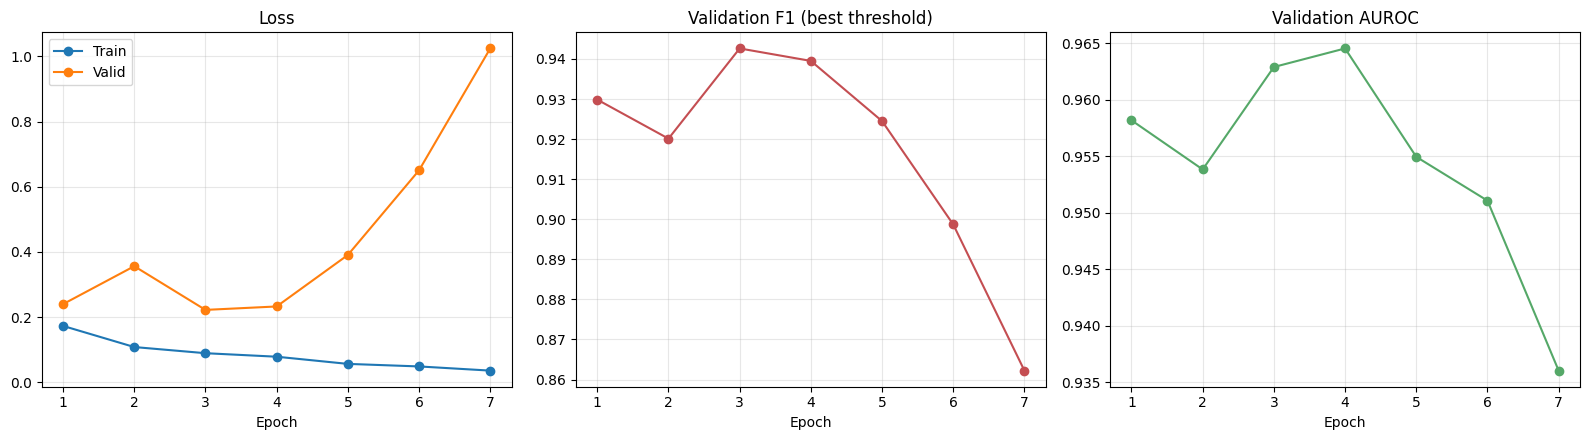

Saved: training_curves.png, training_history.csv


In [16]:
# ============================================================
# 12.1 LOSS / F1 / AUC OVER EPOCHS
# ============================================================
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs_range, history["valid_loss"], marker="o", label="Valid")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["valid_f1"], marker="o", color="#C44E52")
axes[1].set_title("Validation F1 (best threshold)")
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["valid_auc"], marker="o", color="#55A868")
axes[2].set_title("Validation AUROC")
axes[2].set_xlabel("Epoch")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(WORKING_DIR / "training_curves.png", dpi=200)
plt.show()

pd.DataFrame(history).to_csv(WORKING_DIR / "training_history.csv", index=False)
print("Saved: training_curves.png, training_history.csv")


## 13. Test set evaluation

Loads the best checkpoint (by validation F1) and runs it on the held-out test set exactly once, using the classification threshold selected on validation -- the test labels are never used to pick a threshold or otherwise tune anything.

In [17]:
# ============================================================
# 13.1 LOAD BEST CHECKPOINT AND EVALUATE ON TEST
# ============================================================
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
test_threshold = float(checkpoint["threshold"])

print(f"Loaded checkpoint from epoch {checkpoint['epoch']} (validation F1={checkpoint['valid_f1']:.4f})")
print(f"Using validation-selected threshold: {test_threshold:.3f}")

_, test_y, test_probs = run_epoch(model, test_loader, criterion, optimizer, scaler, DEVICE, train=False)
test_pred = (test_probs >= test_threshold).astype(int)

test_metrics = compute_metrics(test_y, test_probs, test_threshold)

print("\n" + "=" * 60)
print("TEST SET METRICS")
print("=" * 60)
for name, value in test_metrics.items():
    print(f"{name:20s}: {value:.4f}" if isinstance(value, float) else f"{name:20s}: {value}")

print("\nClassification report:")
print(classification_report(test_y, test_pred, target_names=["Non-toxic (0)", "Toxic (1)"], digits=4, zero_division=0))


Loaded checkpoint from epoch 3 (validation F1=0.9426)
Using validation-selected threshold: 0.950


Valid:   0%|          | 0/125 [00:00<?, ?it/s]


TEST SET METRICS
threshold           : 0.9500
accuracy            : 0.5495
balanced_accuracy   : 0.5495
precision           : 0.5266
recall              : 0.9810
f1                  : 0.6853
mcc                 : 0.1960
auc                 : 0.7598
auprc               : 0.6901

Classification report:
               precision    recall  f1-score   support

Non-toxic (0)     0.8613    0.1180    0.2076      1000
    Toxic (1)     0.5266    0.9810    0.6853      1000

     accuracy                         0.5495      2000
    macro avg     0.6939    0.5495    0.4464      2000
 weighted avg     0.6939    0.5495    0.4464      2000



## 14. Results visualization

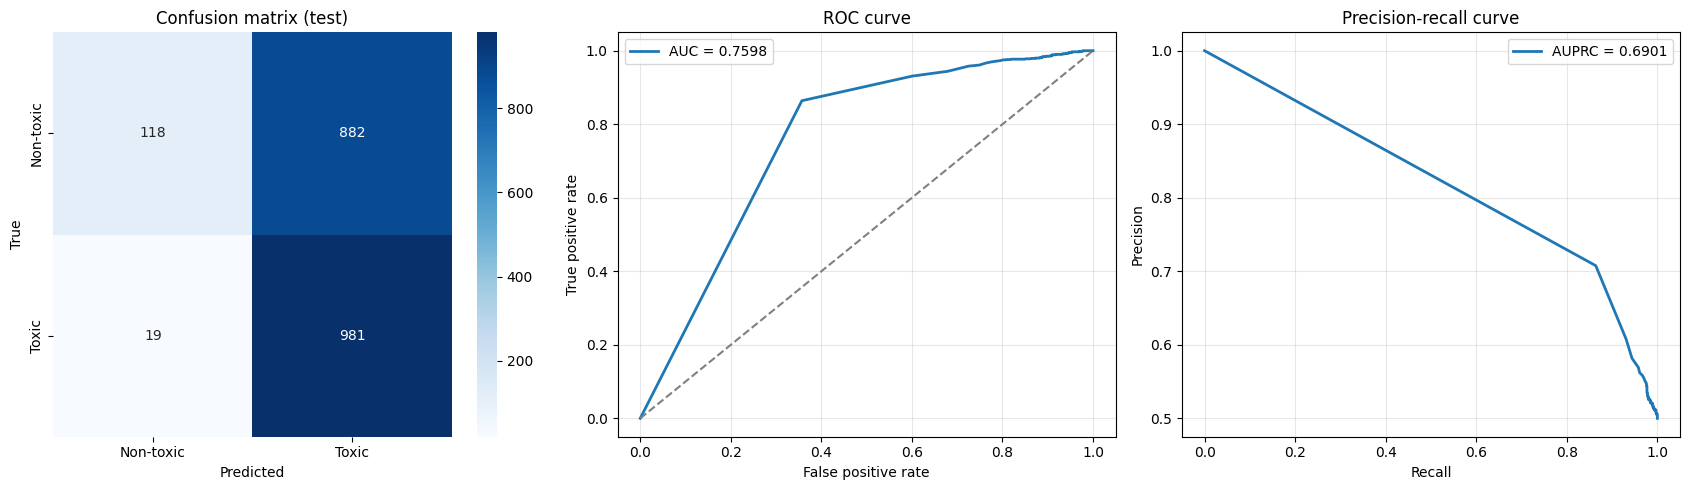

In [18]:
# ============================================================
# 14.1 CONFUSION MATRIX + ROC + PRECISION-RECALL
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

cm = confusion_matrix(test_y, test_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Non-toxic", "Toxic"], yticklabels=["Non-toxic", "Toxic"])
axes[0].set_title("Confusion matrix (test)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

if len(np.unique(test_y)) > 1:
    fpr, tpr, _ = roc_curve(test_y, test_probs)
    axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {test_metrics['auc']:.4f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
    axes[1].set_title("ROC curve")
    axes[1].set_xlabel("False positive rate")
    axes[1].set_ylabel("True positive rate")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    precision_curve, recall_curve, _ = precision_recall_curve(test_y, test_probs)
    axes[2].plot(recall_curve, precision_curve, linewidth=2, label=f"AUPRC = {test_metrics['auprc']:.4f}")
    axes[2].set_title("Precision-recall curve")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(WORKING_DIR / "test_evaluation.png", dpi=200)
plt.show()


## 15. Save artifacts & conclusion

In [19]:
# ============================================================
# 15.1 SAVE TEST PREDICTIONS + METRICS REPORT
# ============================================================
import json

predictions_df = pd.DataFrame({
    "audio_path": test_df["audio_path"] if "audio_path" in test_df.columns else test_df[cols["audio"]],
    "y_true": test_y.astype(int),
    "prob_toxic": test_probs,
    "y_pred": test_pred,
})
predictions_path = WORKING_DIR / "test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

metrics_path = WORKING_DIR / CONFIG["output"]["metrics_name"]
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump({
        "test_metrics": test_metrics,
        "best_epoch": checkpoint["epoch"],
        "best_valid_f1": checkpoint["valid_f1"],
        "num_train": len(train_dataset),
        "num_val": len(val_dataset),
        "num_test": len(test_dataset),
        "config": CONFIG,
    }, f, indent=2, ensure_ascii=False, default=str)

print("Saved:")
print(f"  - Model checkpoint  : {CHECKPOINT_PATH}")
print(f"  - Test predictions  : {predictions_path}")
print(f"  - Metrics report    : {metrics_path}")
print(f"  - Training history  : {WORKING_DIR / 'training_history.csv'}")
print(f"  - Training curves   : {WORKING_DIR / 'training_curves.png'}")
print(f"  - Test evaluation   : {WORKING_DIR / 'test_evaluation.png'}")

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Model              : AST ({CONFIG['model']['checkpoint']})")
print(f"Best epoch         : {checkpoint['epoch']}")
print(f"Decision threshold : {test_threshold:.3f}")
print(f"Test F1            : {test_metrics['f1']:.4f}")
print(f"Test AUROC         : {test_metrics['auc']:.4f}")
print(f"Test balanced acc. : {test_metrics['balanced_accuracy']:.4f}")


Saved:
  - Model checkpoint  : /kaggle/working/best_ast_toxic_classifier.pt
  - Test predictions  : /kaggle/working/test_predictions.csv
  - Metrics report    : /kaggle/working/test_metrics.json
  - Training history  : /kaggle/working/training_history.csv
  - Training curves   : /kaggle/working/training_curves.png
  - Test evaluation   : /kaggle/working/test_evaluation.png

FINAL SUMMARY
Model              : AST (MIT/ast-finetuned-audioset-10-10-0.4593)
Best epoch         : 3
Decision threshold : 0.950
Test F1            : 0.6853
Test AUROC         : 0.7598
Test balanced acc. : 0.5495


## Conclusion & next steps

- The best checkpoint (by validation F1) is saved to `best_ast_toxic_classifier.pt` under the working directory, together with the exact `CONFIG` it was trained with -- reload it with `ASTToxicClassifier(...); model.load_state_dict(torch.load(...)["model_state_dict"])`.
- To retrain with different settings, edit `CONFIG` in Section 2 -- e.g. raise `train.epochs`, change `train.batch_size` for a different GPU, set `model.freeze_first_n_layers > 0` for a faster/lighter fine-tune, or point `paths` at a different dataset export.
- `test_predictions.csv` has one row per test clip (`audio_path`, `y_true`, `prob_toxic`, `y_pred`) -- useful for error analysis (e.g. listening to the highest-confidence false positives/negatives) beyond the aggregate metrics above.
- This notebook intentionally fine-tunes a single, well-understood pretrained model end to end rather than re-introducing a multi-architecture benchmark harness; if a multi-model comparison is needed again later, `MODEL_REGISTRY`-style extensibility can be reintroduced around this same data/training pipeline.
